In [163]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Use the local data folder directly.
data_dir = Path(r'd:\ML-AI\AI in HealthCare\data')
if not (data_dir / 'hosp').exists() or not (data_dir / 'icu').exists():
    raise FileNotFoundError(
        f"Local data folder not found at {data_dir}.\n"
        "Make sure the notebook is running on your local machine and that the data path is correct."
    )
print('Using data folder:', data_dir)
print('patients file exists:', (data_dir / 'hosp' / 'patients.csv.gz').exists())

Using data folder: d:\ML-AI\AI in HealthCare\data
patients file exists: True


In [164]:
# Load patients data
patients = pd.read_csv(data_dir / 'hosp' / 'patients.csv.gz', compression='gzip')

In [165]:
# Load admissions data
admissions = pd.read_csv(data_dir / 'hosp' / 'admissions.csv.gz', compression='gzip')

In [166]:
# Load diagnoses_icd data
diagnoses = pd.read_csv(data_dir / 'hosp' / 'diagnoses_icd.csv.gz', compression='gzip')

In [167]:
# Load ICUSTAYS data
icustays = pd.read_csv(data_dir / 'icu' / 'icustays.csv.gz', compression='gzip')

In [168]:
# Load D_ICD_DIAGNOSES data
diagnoses_labels = pd.read_csv(data_dir / 'hosp' / 'd_icd_diagnoses.csv.gz', compression='gzip')

## Patients Table

In [169]:
from datetime import datetime

df = patients
# Calculate age from anchor_age and anchor_year if direct dob is missing
if 'dob' in df.columns and 'dod' in df.columns:
    def calculate_age(dob, dod):
        dob_date = datetime.strptime(dob, "%Y-%m-%d %H:%M:%S")
        dod_date = datetime.strptime(dod, "%Y-%m-%d %H:%M:%S")
        age = (dod_date - dob_date).days // 365
        return age
    df['age'] = df.apply(lambda row: calculate_age(row['dob'], row['dod']), axis=1)
else:
    df['age'] = df['anchor_age']

# Filter out rows with age greater than or equal to 120
filtered_df = df[df['age'] < 120]

# Display the updated DataFrame
print(filtered_df.head())

   subject_id gender  anchor_age  anchor_year anchor_year_group         dod  \
0    10014729      F          21         2125       2011 - 2013         NaN   
1    10003400      F          72         2134       2011 - 2013  2137-09-02   
2    10002428      F          80         2155       2011 - 2013         NaN   
3    10032725      F          38         2143       2011 - 2013  2143-03-30   
4    10027445      F          48         2142       2011 - 2013  2146-02-09   

   age  
0   21  
1   72  
2   80  
3   38  
4   48  


In [170]:
if 'expire_flag' in filtered_df.columns:
    print(filtered_df['expire_flag'].value_counts())
else:
    print('Column expire_flag not found in patients data. Available columns:', filtered_df.columns.tolist())


Column expire_flag not found in patients data. Available columns: ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'age']


In [171]:
filtered_df["age"].value_counts()

66    5
63    5
67    4
78    4
64    4
60    3
70    3
65    3
59    3
53    3
91    3
48    3
52    3
45    2
34    2
83    2
44    2
43    2
28    2
84    2
87    2
72    2
69    2
82    2
58    2
56    2
57    2
55    2
46    2
51    2
77    1
61    1
47    1
79    1
81    1
76    1
21    1
37    1
88    1
29    1
74    1
86    1
40    1
50    1
71    1
89    1
26    1
38    1
80    1
62    1
Name: age, dtype: int64

In [172]:
filtered_df["gender"].value_counts()

M    57
F    43
Name: gender, dtype: int64

In [173]:
filtered_df['age'].describe()

count    100.00000
mean      61.75000
std       16.16979
min       21.00000
25%       51.75000
50%       63.00000
75%       72.00000
max       91.00000
Name: age, dtype: float64

In [174]:
filtered_df['age'].loc[df['gender'] == 'F'].describe()

count    43.000000
mean     60.813953
std      18.074259
min      21.000000
25%      49.000000
50%      63.000000
75%      73.000000
max      91.000000
Name: age, dtype: float64

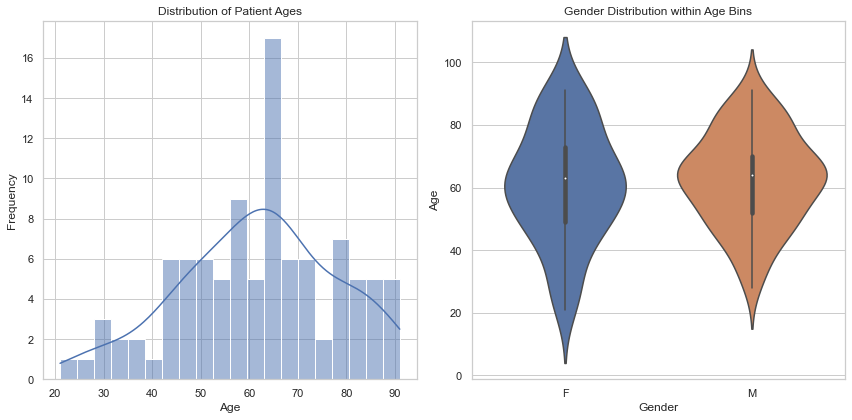

In [175]:
# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# First subplot - Age distribution
plt.subplot(1, 2, 1)
sns.histplot(data=filtered_df, x='age', bins=20, kde=True)
plt.title("Distribution of Patient Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")

# Second subplot - Gender distribution within each age bin
plt.subplot(1, 2, 2)
sns.violinplot(data=filtered_df, x='gender', y='age', inner='box')
plt.title("Gender Distribution within Age Bins")
plt.xlabel("Gender")
plt.ylabel("Age")

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Patients and Admissions Table

In [176]:
# Merge admissions and patients data on subject_id
merged_data = pd.merge(admissions, filtered_df, on="subject_id")
merged_data.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group,dod,age
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,...,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0,M,47,2196,2014 - 2016,NaN,47
1,10004235,22187210,2196-06-20 21:11:00,2196-06-22 13:30:00,NaN,DIRECT EMER.,P98TAU,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,...,BLACK/CAPE VERDEAN,NaN,NaN,0,M,47,2196,2014 - 2016,NaN,47
2,10004235,25970245,2196-06-14 08:30:00,2196-06-19 14:54:00,NaN,SURGICAL SAME DAY ADMISSION,P96Y5O,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,...,BLACK/CAPE VERDEAN,NaN,NaN,0,M,47,2196,2014 - 2016,NaN,47
3,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,...,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0,M,58,2153,2011 - 2013,NaN,58
4,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,...,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0,M,79,2133,2011 - 2013,2134-10-28,79


In [177]:
# Safety: ensure categorical columns exist before plotting
print('merged_data columns before safety fill:', merged_data.columns.tolist())
categorical_cols = ['religion','ethnicity','admission_location','admission_type','insurance','discharge_location','gender']
for c in categorical_cols:
    if c not in merged_data.columns:
        merged_data[c] = 'Unknown'
print('merged_data columns after safety fill:', merged_data.columns.tolist())


merged_data columns before safety fill: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'age']
merged_data columns after safety fill: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'age', 'religion', 'ethnicity']


In [178]:
merged_data['admission_type'].value_counts()

EW EMER.                       104
OBSERVATION ADMIT               45
URGENT                          38
EU OBSERVATION                  30
SURGICAL SAME DAY ADMISSION     18
DIRECT EMER.                    15
ELECTIVE                        13
DIRECT OBSERVATION               7
AMBULATORY OBSERVATION           5
Name: admission_type, dtype: int64

In [179]:
merged_data['admission_location'].value_counts()

EMERGENCY ROOM                            134
PHYSICIAN REFERRAL                         63
TRANSFER FROM HOSPITAL                     43
CLINIC REFERRAL                            10
WALK-IN/SELF REFERRAL                       7
PROCEDURE SITE                              7
TRANSFER FROM SKILLED NURSING FACILITY      4
PACU                                        4
INTERNAL TRANSFER TO OR FROM PSYCH          2
INFORMATION NOT AVAILABLE                   1
Name: admission_location, dtype: int64

In [180]:
merged_data['insurance'].value_counts()

Other       149
Medicare    104
Medicaid     22
Name: insurance, dtype: int64

In [181]:
merged_data['discharge_location'].value_counts()

HOME HEALTH CARE                76
HOME                            72
SKILLED NURSING FACILITY        36
DIED                            15
REHAB                           13
CHRONIC/LONG TERM ACUTE CARE     9
HOSPICE                          5
AGAINST ADVICE                   4
PSYCH FACILITY                   2
ACUTE HOSPITAL                   1
Name: discharge_location, dtype: int64

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'SKILLED NURSING FACILITY'),
  Text(1, 0, 'HOME HEALTH CARE'),
  Text(2, 0, 'CHRONIC/LONG TERM ACUTE CARE'),
  Text(3, 0, 'DIED'),
  Text(4, 0, 'HOME'),
  Text(5, 0, 'REHAB'),
  Text(6, 0, 'AGAINST ADVICE'),
  Text(7, 0, 'HOSPICE'),
  Text(8, 0, 'ACUTE HOSPITAL'),
  Text(9, 0, 'PSYCH FACILITY')])

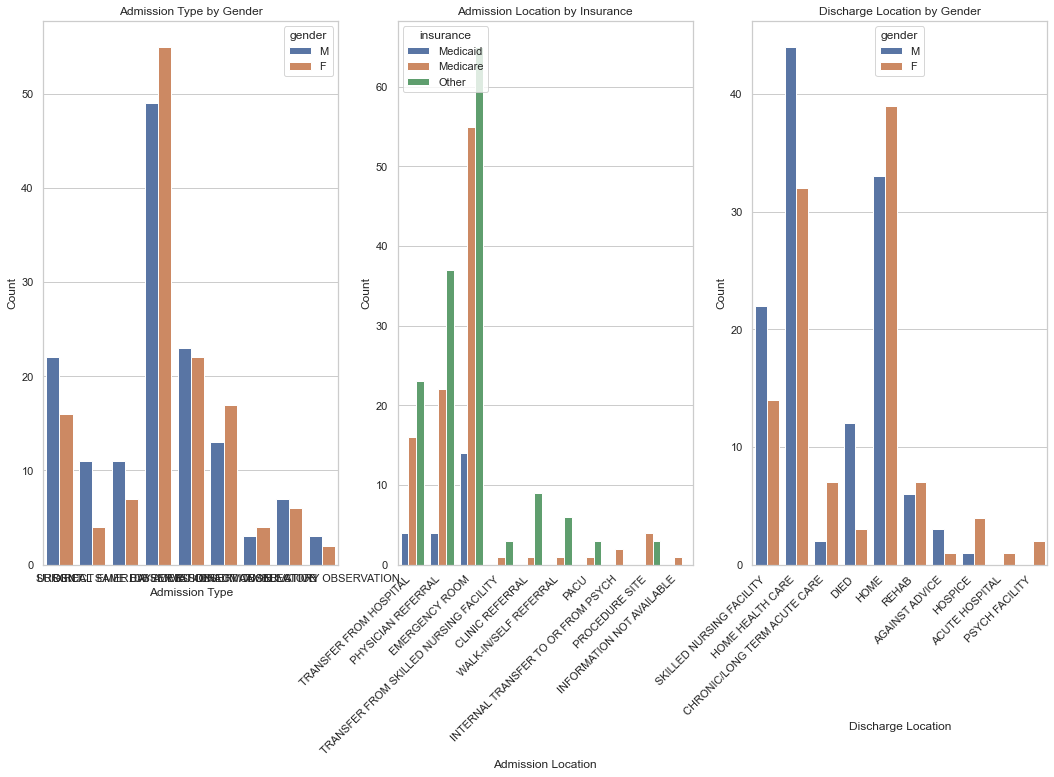

In [182]:
# Create a complex visualization
plt.figure(figsize=(18, 10))

# Analysis 1: Count plot of Admission Types by Gender
plt.subplot(1, 3, 1)
sns.countplot(data=merged_data, x='admission_type', hue='gender')
plt.title("Admission Type by Gender")
plt.xlabel("Admission Type")
plt.ylabel("Count")

# Analysis 2: Count plot of Admission Locations by Insurance
plt.subplot(1, 3, 2)
sns.countplot(data=merged_data, x='admission_location', hue='insurance')
plt.title("Admission Location by Insurance")
plt.xlabel("Admission Location")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')

# Analysis 3: Count plot of Discharge Locations by Gender
plt.subplot(1, 3, 3)
sns.countplot(data=merged_data, x='discharge_location', hue='gender')
plt.title("Discharge Location by Gender")
plt.xlabel("Discharge Location")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')

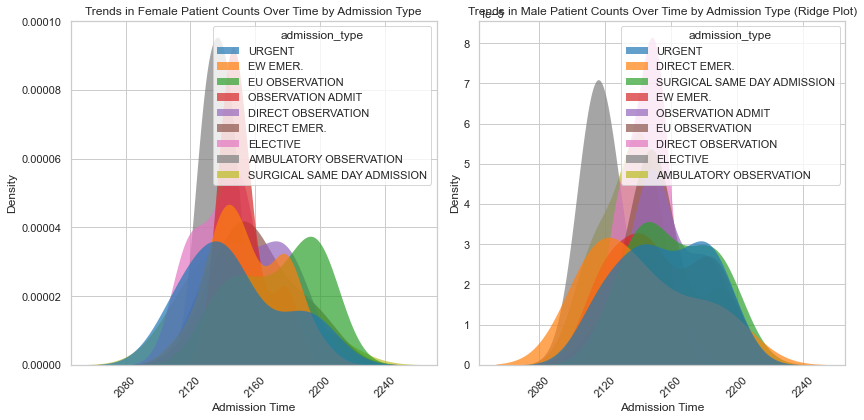

In [183]:
merged_data['admittime'] = pd.to_datetime(merged_data['admittime'])  # Convert to datetime

# Filter data for male and female patients
male_data = merged_data[merged_data['gender'] == 'M']
female_data = merged_data[merged_data['gender'] == 'F']

# Create separate Ridge Plots for male and female patients
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(data=female_data, x='admittime', hue='admission_type', fill=True, common_norm=False, palette='tab10', alpha=0.7, linewidth=0, label='Female')
plt.xlabel('Admission Time')
plt.ylabel('Density')
plt.title('Trends in Female Patient Counts Over Time by Admission Type')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.kdeplot(data=male_data, x='admittime', hue='admission_type', fill=True, common_norm=False, palette='tab10', alpha=0.7, linewidth=0, label='Male')
plt.xlabel('Admission Time')
plt.ylabel('Density')
plt.title('Trends in Male Patient Counts Over Time by Admission Type (Ridge Plot)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Different types of plots that convey same information

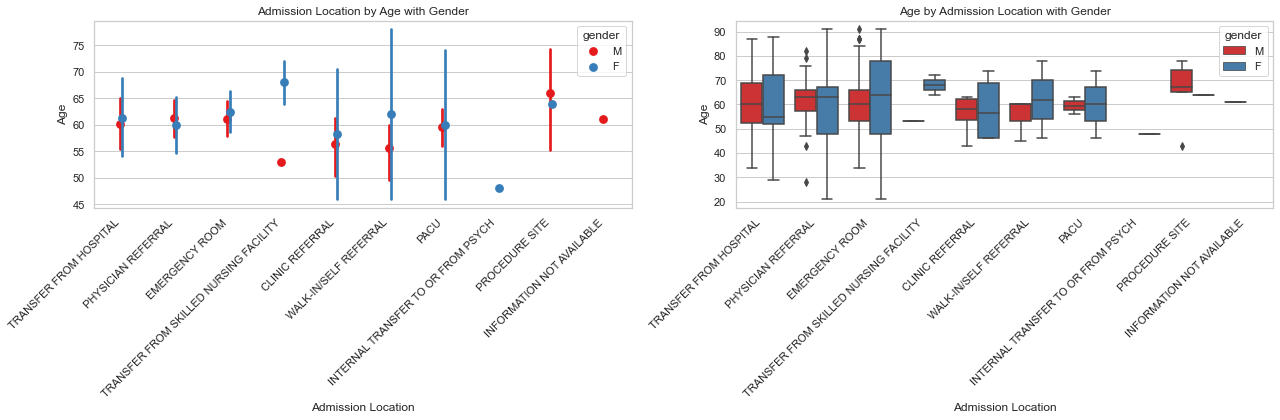

In [184]:
# Create a complex visualization using subplots
plt.figure(figsize=(18, 6))

# Point plot of Admission Location by Age with Gender color hue
plt.subplot(1, 2, 1)
sns.pointplot(data=merged_data, x='admission_location', y='age', hue='gender', palette='Set1', dodge=True, linestyles="")
plt.title("Admission Location by Age with Gender")
plt.xlabel("Admission Location")
plt.ylabel("Age")
plt.xticks(rotation=45, ha='right')

# Box plot of Age by Admission Location with Gender color hue
plt.subplot(1, 2, 2)
sns.boxplot(data=merged_data, x='admission_location', y='age', hue='gender', palette='Set1')
plt.title("Age by Admission Location with Gender")
plt.xlabel("Admission Location")
plt.ylabel("Age")
plt.xticks(rotation=45, ha='right')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [185]:
if 'religion' in merged_data.columns:
    print(merged_data['religion'].value_counts())
else:
    print("Column 'religion' not found; available columns:", merged_data.columns.tolist())


Unknown    275
Name: religion, dtype: int64


In [186]:
merged_data['ethnicity'].value_counts()

Unknown    275
Name: ethnicity, dtype: int64

## Heatmap

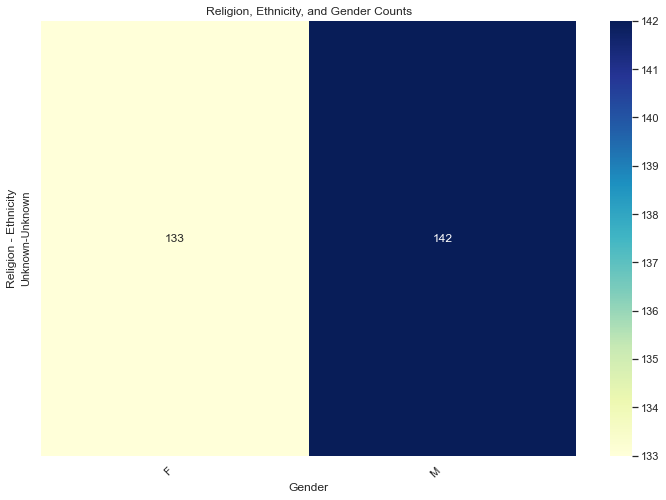

In [187]:
# Create a pivot table to prepare data for the heatmap
pivot_table = merged_data.groupby(['religion', 'ethnicity', 'gender']).size().unstack().fillna(0)

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='g', cmap='YlGnBu')
plt.title("Religion, Ethnicity, and Gender Counts")
plt.xlabel("Gender")
plt.ylabel("Religion - Ethnicity")
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.show()

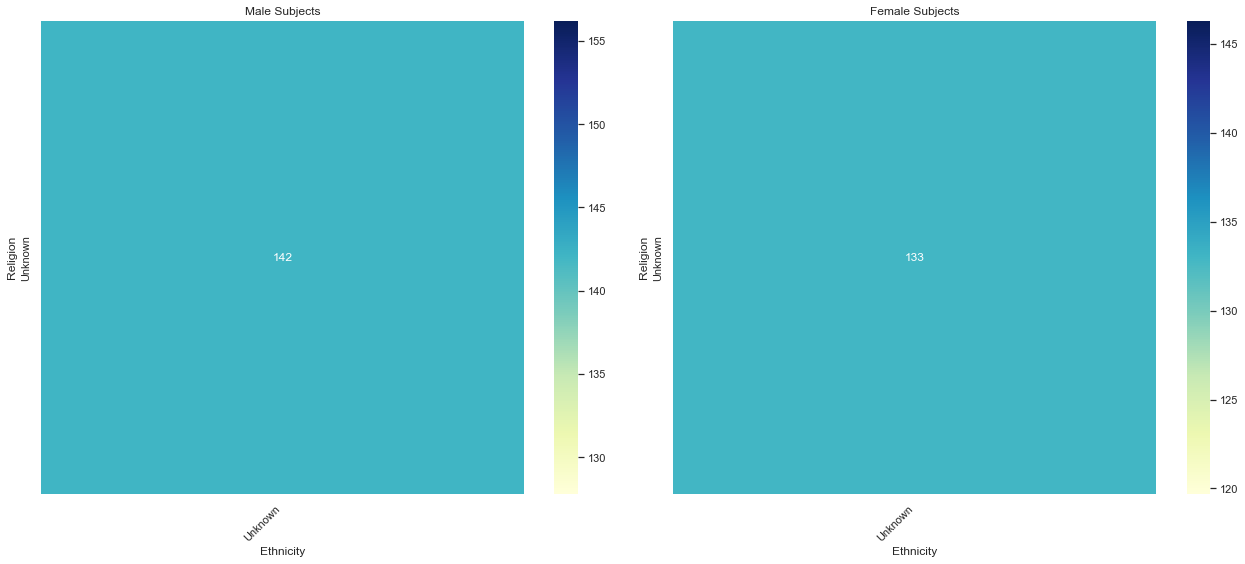

In [188]:
# Create a cross-tabulation of religion, ethnicity, and gender
cross_tab = pd.crosstab(index=[merged_data['religion'], merged_data['ethnicity']], columns=merged_data['gender'])

# Reset the index for better plot compatibility
cross_tab = cross_tab.reset_index()

# Melt the cross-tabulation for heatmaps
melted_cross_tab = pd.melt(cross_tab, id_vars=['religion', 'ethnicity'], value_vars=['M', 'F'], var_name='gender')

# Create separate heatmaps for male and female subjects using subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))

# Male Subjects Heatmap
male_pivot = melted_cross_tab[melted_cross_tab['gender'] == 'M'].pivot_table(index='religion', columns='ethnicity', values='value', aggfunc='sum', fill_value=0)
sns.heatmap(male_pivot, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0])
axes[0].set_title("Male Subjects")
axes[0].set_xlabel("Ethnicity")
axes[0].set_ylabel("Religion")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Female Subjects Heatmap
female_pivot = melted_cross_tab[melted_cross_tab['gender'] == 'F'].pivot_table(index='religion', columns='ethnicity', values='value', aggfunc='sum', fill_value=0)
sns.heatmap(female_pivot, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1])
axes[1].set_title("Female Subjects")
axes[1].set_xlabel("Ethnicity")
axes[1].set_ylabel("Religion")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Patients, Admissions, and Diagnosis_icd Tables

In [189]:
# Build ICD mapping robustly from diagnoses_labels
possible_key_cols = ['icd9_code', 'icd_code']
possible_title_cols = ['short_title', 'long_title']
key_col = next((c for c in possible_key_cols if c in diagnoses_labels.columns), None)
title_col = next((c for c in possible_title_cols if c in diagnoses_labels.columns), None)

if key_col is None or title_col is None:
    print('Cannot build ICD mapping; available columns in diagnoses_labels:', diagnoses_labels.columns.tolist())
    icd9_dict = {}
else:
    # Ensure keys are strings to match codes in diagnoses table
    icd9_dict = pd.Series(diagnoses_labels[title_col].astype(str).values,
                          index=diagnoses_labels[key_col].astype(str)).to_dict()
    print('ICD mapping built using', key_col, '->', title_col)
    # show a small sample
    sample_items = list(icd9_dict.items())[:5]
    print('sample mapping:', sample_items)

# Use icd9_dict safely in downstream code (missing mappings will return NaN when used)

ICD mapping built using icd_code -> long_title
sample mapping: [('0090', 'Infectious colitis, enteritis, and gastroenteritis'), ('01160', 'Tuberculous pneumonia [any form], unspecified'), ('01186', 'Other specified pulmonary tuberculosis, tubercle bacilli not found by bacteriological or histological examination, but tuberculosis confirmed by other methods [inoculation of animals]'), ('01200', 'Tuberculous pleurisy, unspecified'), ('01236', 'Tuberculous laryngitis, tubercle bacilli not found by bacteriological or histological examination, but tuberculosis confirmed by other methods [inoculation of animals]')]


Creating a dictionary instead of joining two tables is more efficient. However, the impact depends on several factors. Proper indexing, query optimization, and consideration of your specific database system and hardware resources can help mitigate performance issues when joining tables, whereas creating a dictionary is easier and efficient as it uses the concept of hashing.

In [190]:
# Merge diagnosis_icd with admissions on subject_id
# Detect which column stores the diagnosis code (icd9_code vs icd_code)
diag_code_col = next((c for c in ['icd9_code', 'icd_code'] if c in diagnoses.columns), None)

if diag_code_col is None:
    print('No diagnosis code column found in diagnoses table. Available columns:', diagnoses.columns.tolist())
    merged_data_diagnosis = pd.merge(merged_data, diagnoses, on='subject_id', how='inner')
    # Empty series placeholders to avoid downstream errors
    top_diagnosis_codes_male = pd.Series(dtype=int)
    top_diagnosis_codes_female = pd.Series(dtype=int)
else:
    merged_data_diagnosis = pd.merge(merged_data, diagnoses, on='subject_id', how='inner')
    print('Using diagnosis code column:', diag_code_col)
    # Normalize to string before counting
    top_diagnosis_codes_male = merged_data_diagnosis[merged_data_diagnosis['gender'] == 'M'][diag_code_col].astype(str).value_counts().head(10)
    top_diagnosis_codes_female = merged_data_diagnosis[merged_data_diagnosis['gender'] == 'F'][diag_code_col].astype(str).value_counts().head(10)

Using diagnosis code column: icd_code


C:\Users\luisv\AppData\Local\Temp\ipykernel_12644\410955508.py:36: UserWarning:

Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations



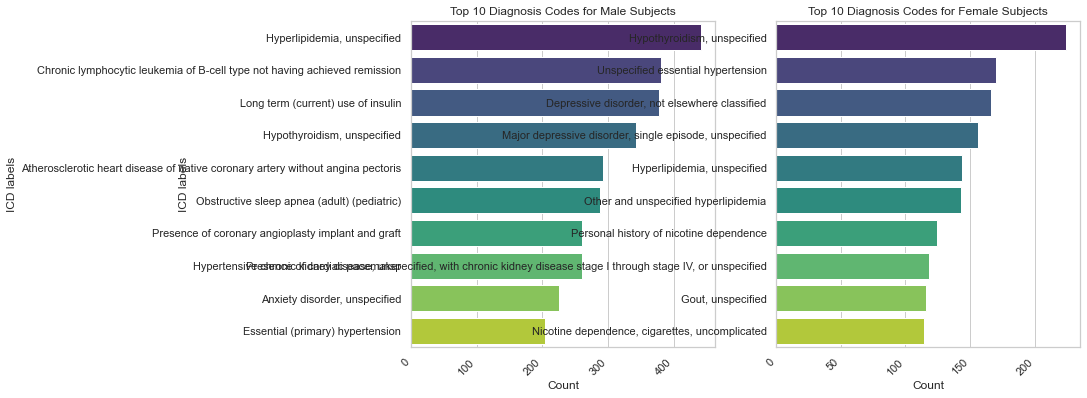

In [191]:
# Create a figure with subplots
plt.figure(figsize=(12, 6))

# Subplot for Male Subjects
plt.subplot(1, 2, 1)
if not top_diagnosis_codes_male.empty:
    sns.barplot(x=top_diagnosis_codes_male.values, y=top_diagnosis_codes_male.index, palette='viridis')
    plt.title("Top 10 Diagnosis Codes for Male Subjects")
    plt.xlabel("Count")
    plt.ylabel("ICD labels")
    plt.xticks(rotation=45, ha='right')

    # Label the y-axis ticks with titles using mapping safely
    male_codes = [str(c) for c in top_diagnosis_codes_male.index]
    male_short_titles = [icd9_dict.get(code, code) for code in male_codes]
    plt.yticks(range(len(male_short_titles)), male_short_titles)
else:
    plt.text(0.5, 0.5, 'No male diagnosis codes available', ha='center')

# Subplot for Female Subjects
plt.subplot(1, 2, 2)
if not top_diagnosis_codes_female.empty:
    sns.barplot(x=top_diagnosis_codes_female.values, y=top_diagnosis_codes_female.index, palette='viridis')
    plt.title("Top 10 Diagnosis Codes for Female Subjects")
    plt.xlabel("Count")
    plt.ylabel("ICD labels")
    plt.xticks(rotation=45, ha='right')

    female_codes = [str(c) for c in top_diagnosis_codes_female.index]
    female_short_titles = [icd9_dict.get(code, code) for code in female_codes]
    plt.yticks(range(len(female_short_titles)), female_short_titles)
else:
    plt.text(0.5, 0.5, 'No female diagnosis codes available', ha='center')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

The above plots can be visualized using another python library Plotly. The plots are more interactive and easy to visualize

In [192]:
import pandas as pd
import plotly.graph_objects as go

# Create DataFrames for male and female diagnosis codes using a generic 'code' column
male_df = pd.DataFrame({'code': top_diagnosis_codes_male.index.astype(str), 'count': top_diagnosis_codes_male.values})
female_df = pd.DataFrame({'code': top_diagnosis_codes_female.index.astype(str), 'count': top_diagnosis_codes_female.values})

# Map ICD codes to labels safely, falling back to the code when no label exists
male_df['labels'] = male_df['code'].map(icd9_dict).fillna(male_df['code'])
female_df['labels'] = female_df['code'].map(icd9_dict).fillna(female_df['code'])

# Create hover text
male_df['hover_text'] = male_df['code'] + '<br>Disease name: ' + male_df['labels'] + '<br>ICD Code: ' + male_df['code'] + '<br>Count: ' + male_df['count'].astype(str)
female_df['hover_text'] = female_df['code'] + '<br>Disease name: ' + female_df['labels'] + '<br>ICD Code: ' + female_df['code'] + '<br>Count: ' + female_df['count'].astype(str)

# Create treemaps using Plotly Graph Objects with custom hover data and template
fig_male = go.Figure(go.Treemap(
    labels=male_df['labels'],
    parents=[''] * len(male_df),  # Set parent to empty string to remove parent levels
    values=male_df['count'],
    customdata=male_df[['code', 'hover_text']],
    hovertemplate='<b>%{customdata[0]}</b><br>%{customdata[1]}',
))
fig_male.update_layout(title='Top Diagnosis Codes for Male Subjects')

fig_female = go.Figure(go.Treemap(
    labels=female_df['labels'],
    parents=[''] * len(female_df),  # Set parent to empty string to remove parent levels
    values=female_df['count'],
    customdata=female_df[['code', 'hover_text']],
    hovertemplate='<b>%{customdata[0]}</b><br>%{customdata[1]}',
))
fig_female.update_layout(title='Top Diagnosis Codes for Female Subjects')

# Show the treemaps
fig_male.show()
fig_female.show()

##Time series plots

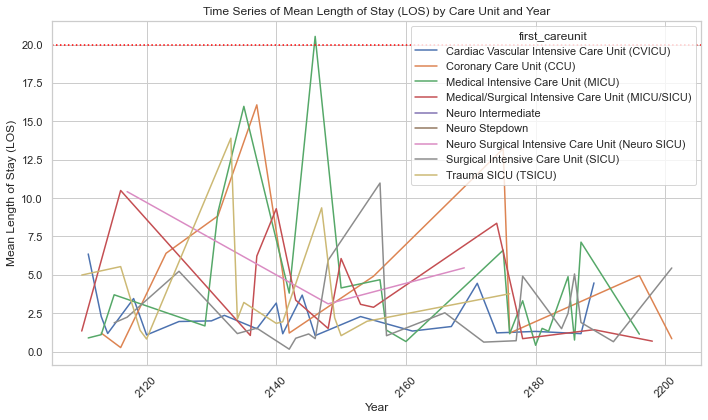

In [193]:
icustays['intime'] = pd.to_datetime(icustays['intime'])
icustays['outtime'] = pd.to_datetime(icustays['outtime'])

# Extract the year from 'intime'
icustays['intime_year'] = icustays['intime'].dt.year

# Calculate the mean LOS for each care unit and year
los_stats = icustays.groupby(['first_careunit', 'intime_year'])['los'].mean().reset_index()

# Plot the time series of mean LOS by care unit and year
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

sns.lineplot(data=los_stats, x='intime_year', y='los', hue='first_careunit')

# Add a horizontal dotted line to identify the threshold
threshold = 20  # Set your threshold value here
plt.axhline(y=threshold, color='red', linestyle='dotted', label=f'Threshold ({threshold})')

plt.title("Time Series of Mean Length of Stay (LOS) by Care Unit and Year")
plt.xlabel("Year")
plt.ylabel("Mean Length of Stay (LOS)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [194]:
# Create an interactive line plot using Plotly Express
import plotly.express as px
fig = px.line(los_stats, x='intime_year', y='los', color='first_careunit',
              title='Time Series of Mean Length of Stay (LOS) by Care Unit and Year',
              labels={'intime_year': 'Year', 'los': 'Mean Length of Stay (LOS)'},
              template='plotly_white')

# Add a horizontal line to indicate the threshold
fig.add_hline(y=threshold, line_dash="dash", line_color="red", annotation_text=f'Threshold ({threshold})')

# Rotate x-axis labels for better readability
fig.update_xaxes(tickangle=45)

# Show the interactive plot
fig.show()

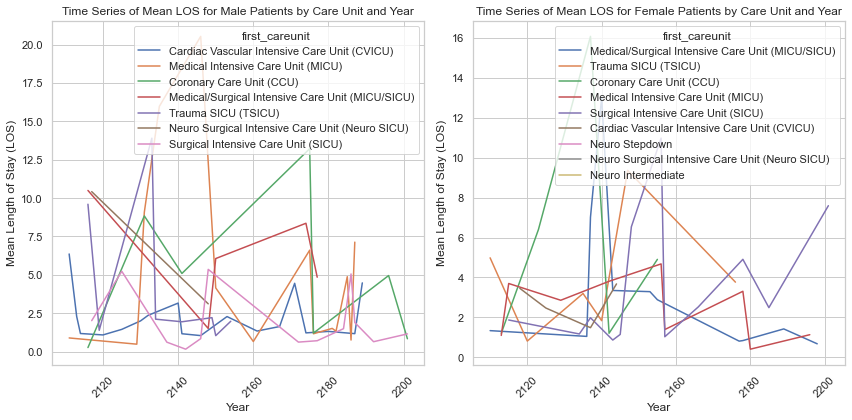

In [195]:
# Merge icustays, admissions and patients on subject_id
merged_data_icu = pd.merge(icustays, merged_data, on='subject_id', how='inner')

# Extract the year from 'intime'
merged_data_icu['intime_year'] = merged_data_icu['intime'].dt.year

# Filter data for male and female patients
male_data = merged_data_icu[merged_data_icu['gender'] == 'M']
female_data = merged_data_icu[merged_data_icu['gender'] == 'F']

# Create separate time series plots for male and female patients
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.set(style="whitegrid")
sns.lineplot(data=male_data.groupby(['intime_year', 'first_careunit'])['los'].mean().reset_index(),
             x='intime_year', y='los', hue='first_careunit')
plt.title("Time Series of Mean LOS for Male Patients by Care Unit and Year")
plt.xlabel("Year")
plt.ylabel("Mean Length of Stay (LOS)")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.set(style="whitegrid")
sns.lineplot(data=female_data.groupby(['intime_year', 'first_careunit'])['los'].mean().reset_index(),
             x='intime_year', y='los', hue='first_careunit')
plt.title("Time Series of Mean LOS for Female Patients by Care Unit and Year")
plt.xlabel("Year")
plt.ylabel("Mean Length of Stay (LOS)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##Scatterplot

Jointplot is primarily used to visualize the relationship between two numeric variables.

Jointplot is typically used to visualize the interaction between two variables and doesn't involve grouping or categorization.

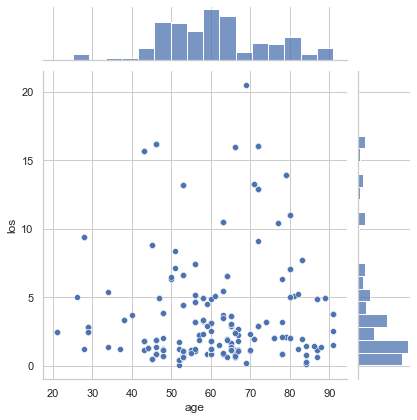

In [196]:
# Create a joint plot using Seaborn
sns.set(style="whitegrid")
sns.jointplot(data=merged_data_icu, x='age', y='los', kind='scatter')
plt.show()

FacetGrid is used for creating a grid of subplots, where each subplot represents a subset of the data based on one or more categorical variables.

FacetGrid allows you to compare different groups or categories within your data and see how relationships or distributions vary across them.

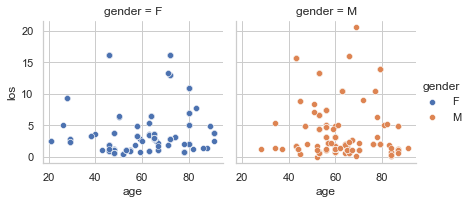

In [197]:
# Create a facet grid of joint plots for each gender
g = sns.FacetGrid(merged_data_icu, col='gender', hue='gender')
g.map(sns.scatterplot, 'age', 'los')
g.add_legend()
plt.show()

In summary, jointplot is used to visualize the relationship between two numeric variables, whereas FacetGrid is used to create a grid of subplots for comparing relationships or distributions within different categorical groups. The choice between the two depends on whether you're focusing on the relationship between two variables (for jointplot) or exploring different aspects of your data across categories (for FacetGrid).